# Model Evaluation And Residuals

The selected model is the one with the lowest backtest WAPE, not the fanciest name.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name != "v7_rm_pm_forecast_planning":
    ROOT = Path("Ai miroservices/modeling/v7_rm_pm_forecast_planning").resolve()
OUT = ROOT / "outputs"
pd.set_option("display.max_columns", 80)

In [2]:
leaderboard = pd.read_csv(OUT / "model_leaderboard.csv")
leaderboard

,model,rows,materials,WAPE,MAE,RMSE,Bias,under_forecast_rate
0,croston_sba,1728,288,0.258377,446.166762,2401.367369,0.031150,0.434606
1,moving_avg_6,1728,288,0.282855,488.434896,2752.240619,0.082323,0.395255
2,moving_avg_3,1728,288,0.289843,500.502894,2724.766406,0.065316,0.400463
3,seasonal_naive,1728,288,0.348246,601.353009,3386.662683,0.075307,0.374421
4,lightgbm_global_rm_pm,1728,288,0.248813,429.651670,2409.802011,0.015064,0.509838


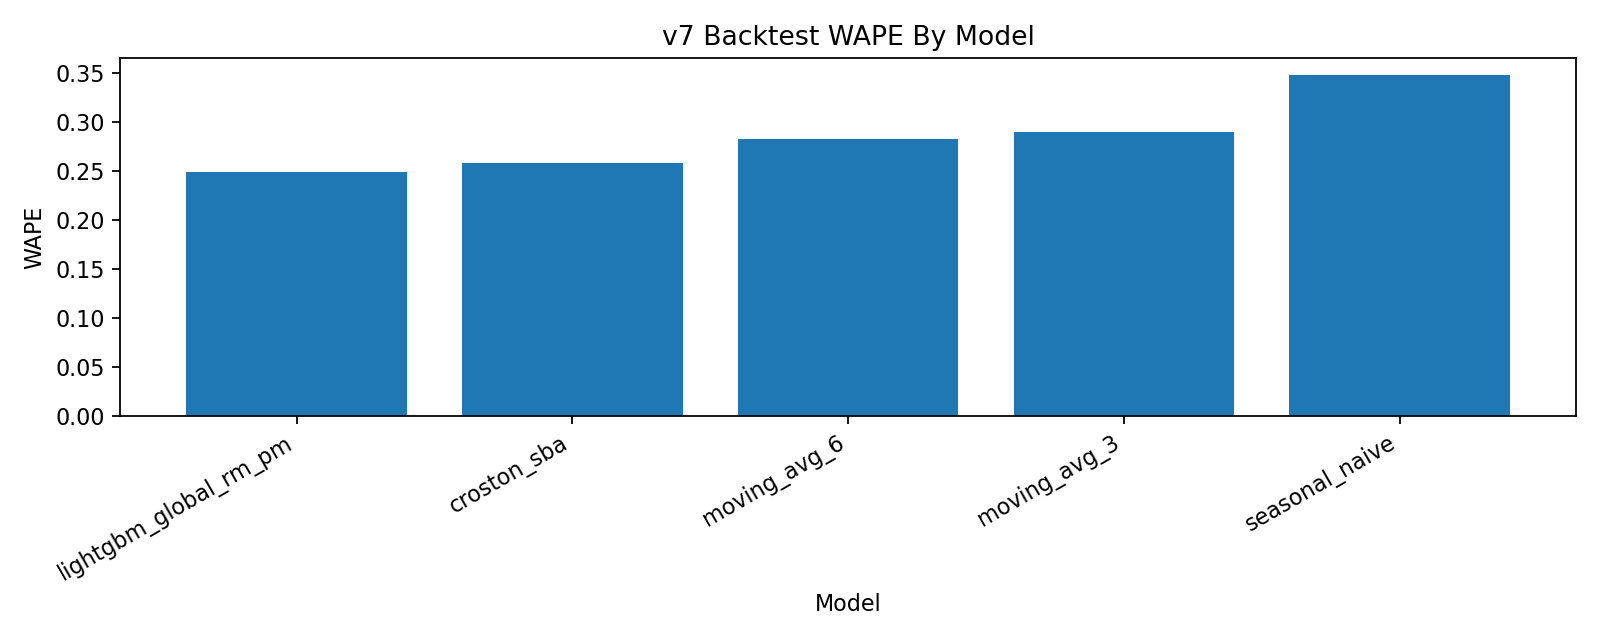

In [3]:
from IPython.display import Image
Image(filename=str(OUT / "plots" / "model_wape_leaderboard.png"))

In [4]:
best = leaderboard.sort_values("WAPE").iloc[0]["model"]
rows = pd.concat([
    pd.read_csv(OUT / "baseline_backtest_rows.csv"),
    pd.read_csv(OUT / "lightgbm_backtest_rows.csv"),
], ignore_index=True)
rows = rows[rows["model"].eq(best)].copy()
rows["residual"] = rows["prediction"] - rows["actual"]
rows[["material_code", "month", "actual", "prediction", "residual"]].head(30)

,material_code,month,actual,prediction,residual
6912,100012,2025-07-01,150.0,114.030594,-35.969406
6913,100012,2025-08-01,103.0,114.086805,11.086805
6914,100012,2025-09-01,196.0,75.643337,-120.356663
6915,100012,2025-10-01,117.0,78.152606,-38.847394
6916,100012,2025-11-01,112.0,106.223190,-5.776810
6917,100012,2025-12-01,112.0,103.461273,-8.538727
6918,101208,2025-07-01,0.0,0.026115,0.026115
6919,101208,2025-08-01,0.0,0.035013,0.035013
6920,101208,2025-09-01,0.0,0.035013,0.035013
6921,101208,2025-10-01,0.0,0.032111,0.032111
